# Standard Cost Comparison for PVC
4/5/2026 - Project Start <br>
Looking to update obsolete standard costs w/ a standardized formula (see below).<br>
$$\text{new\_std\_cost} = \text{avg\_cost} \times (1 + \text{markup})$$

Starting w/ sample data of just PVC materials. Need to see if 25%, 30%, or 35% fits best. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_excel('std_cost_comparison_pvc_data.xlsx')
df.head()

,item_no,item_desc_1,item_desc_2,prod_cat,uom,qty_on_hand,avg_cost,last_cost,std_cost
0,30100122840APET,APET,.012 x 28 x 40,NaN,EA,0,1.500000,1.50,1.875000
1,3010015250523,PVC SHEET CLEAR,.015X25X52,NaN,SH,0,0.000000,0.00,0.000000
2,301002860096ACR,PVC/ACRILIC ALLOY HAIRCELL 1 S,.028 X 60 X 96 BLACK # 4335,NaN,EA,0,25.080000,25.08,31.350000
3,3010030480961,PVC SHEET GRAY,.032 50.5 X 99.5 TYPE I,301.0,SH,10,63.790291,65.32,79.737864
4,3010060210519,PVC SHEET BLACK,".060 x 21"" x 51""",NaN,EA,0,9.670000,9.67,12.087500


## Cleaning
Need to flag rows where average cost (avg_cost) or standard cost (std_cost) is 0. Flagged (..._missing) and to be excluded from analysis. <br>
Output shows # of good and bad rows.

In [2]:
df['avg_cost_missing'] = df['avg_cost'] == 0
df['std_cost_missing'] = df['std_cost'] == 0
print(f'Number of Rows Where Average is 0 = {df["avg_cost_missing"].sum()}')
print(f'Number of Rows Where Standard = 0: {df["std_cost_missing"].sum()}')
print(f'Number of Rows Good = {(~df["avg_cost_missing"] & ~df["std_cost_missing"]).sum()}')

Number of Rows Where Average is 0 = 18
Number of Rows Where Standard = 0: 13
Number of Rows Good = 151


## Apply Formulas
For each markup % (x) we will compute a new standard cost (new_std_x), the difference between the old and new standard costs (diff_x), and the percent change (pct_change_x).

In [3]:
markups = [0.25, 0.30, 0.35]
for m in markups:
    pct = int(m * 100)
    df[f'new_std_{pct}'] = df['avg_cost'] * (1 + m)
    df[f'diff_{pct}']    = df[f'new_std_{pct}'] - df['std_cost']
    df[f'pct_change_{pct}'] = np.where(df['std_cost'] == 0, np.nan, (df[f'new_std_{pct}'] - df['std_cost']) / df['std_cost'])

df.head()

,item_no,item_desc_1,item_desc_2,prod_cat,uom,qty_on_hand,avg_cost,last_cost,std_cost,avg_cost_missing,std_cost_missing,new_std_25,diff_25,pct_change_25,new_std_30,diff_30,pct_change_30,new_std_35,diff_35,pct_change_35
0,30100122840APET,APET,.012 x 28 x 40,NaN,EA,0,1.500000,1.50,1.875000,False,False,1.875000,0.000000e+00,0.000000e+00,1.950000,0.075000,0.04,2.025000,0.150000,0.08
1,3010015250523,PVC SHEET CLEAR,.015X25X52,NaN,SH,0,0.000000,0.00,0.000000,True,True,0.000000,0.000000e+00,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN
2,301002860096ACR,PVC/ACRILIC ALLOY HAIRCELL 1 S,.028 X 60 X 96 BLACK # 4335,NaN,EA,0,25.080000,25.08,31.350000,False,False,31.350000,-3.552714e-15,-1.133242e-16,32.604000,1.254000,0.04,33.858000,2.508000,0.08
3,3010030480961,PVC SHEET GRAY,.032 50.5 X 99.5 TYPE I,301.0,SH,10,63.790291,65.32,79.737864,False,False,79.737864,-2.500000e-07,-3.135273e-09,82.927378,3.189514,0.04,86.116893,6.379029,0.08
4,3010060210519,PVC SHEET BLACK,".060 x 21"" x 51""",NaN,EA,0,9.670000,9.67,12.087500,False,False,12.087500,0.000000e+00,0.000000e+00,12.571000,0.483500,0.04,13.054500,0.967000,0.08


## Output Table
Full table ouput w/ proper value formats.

In [4]:
cols = ['item_no', 'item_desc_1', 'item_desc_2', 'avg_cost', 'std_cost', 'new_std_25', 'diff_25', 'pct_change_25', 'new_std_30', 'diff_30', 'pct_change_30', 'new_std_35', 'diff_35', 'pct_change_35', 'avg_cost_missing', 'std_cost_missing']
comparison = df[cols].copy()
comparison.style.format({'avg_cost': '${:,.2f}', 'std_cost': '${:,.2f}', 'new_std_25': '${:,.2f}', 'new_std_30': '${:,.2f}', 'new_std_35': '${:,.2f}', 'diff_25': '${:,.2f}', 'diff_30': '${:,.2f}', 'diff_35': '${:,.2f}', 'pct_change_25': '{:.1%}', 'pct_change_30': '{:.1%}', 'pct_change_35': '{:.1%}',})

,item_no,item_desc_1,item_desc_2,avg_cost,std_cost,new_std_25,diff_25,pct_change_25,new_std_30,diff_30,pct_change_30,new_std_35,diff_35,pct_change_35,avg_cost_missing,std_cost_missing
0,30100122840APET,APET,.012 x 28 x 40,$1.50,$1.88,$1.88,$0.00,0.0%,$1.95,$0.08,4.0%,$2.03,$0.15,8.0%,False,False
1,3010015250523,PVC SHEET CLEAR,.015X25X52,$0.00,$0.00,$0.00,$0.00,nan%,$0.00,$0.00,nan%,$0.00,$0.00,nan%,True,True
2,301002860096ACR,PVC/ACRILIC ALLOY HAIRCELL 1 S,.028 X 60 X 96 BLACK # 4335,$25.08,$31.35,$31.35,$-0.00,-0.0%,$32.60,$1.25,4.0%,$33.86,$2.51,8.0%,False,False
3,3010030480961,PVC SHEET GRAY,.032 50.5 X 99.5 TYPE I,$63.79,$79.74,$79.74,$-0.00,-0.0%,$82.93,$3.19,4.0%,$86.12,$6.38,8.0%,False,False
4,3010060210519,PVC SHEET BLACK,".060 x 21"" x 51""",$9.67,$12.09,$12.09,$0.00,0.0%,$12.57,$0.48,4.0%,$13.05,$0.97,8.0%,False,False
5,3010060210519,PVC SHEET BLACK,".060 x 21"" x 51""",$0.00,$0.00,$0.00,$0.00,nan%,$0.00,$0.00,nan%,$0.00,$0.00,nan%,True,True
6,3010060480961,PVC SHEET GRAY,.060 X 48 X 96 TYPE I,$24.85,$31.06,$31.06,$-0.00,-0.0%,$32.30,$1.24,4.0%,$33.55,$2.48,8.0%,False,False
7,3010060480962,PVC SHEET WHITE,.060 48X96 TYPE I,$14.75,$18.44,$18.44,$0.00,0.0%,$19.17,$0.74,4.0%,$19.91,$1.47,8.0%,False,False
8,3010060480963,PVC SHEET CLEAR,.060 48 X 96 TYPE I,$28.42,$35.52,$35.52,$0.00,0.0%,$36.94,$1.42,4.0%,$38.36,$2.84,8.0%,False,False
9,3010060480967,PCV SHEET GRAY,.060 48 X 96 TYPE 2,$19.44,$24.30,$24.30,$0.00,0.0%,$25.27,$0.97,4.0%,$26.24,$1.94,8.0%,False,False


## Clean Output
Filter only rows that have both average cost (avg_cost) and standard cost (std_cost).<br>
For each markup % (scenario) we list how many new standard costs were higher (item_higher) or lower (items_lower). <br>
Along w/ mean, median, total difference (..._diff) and mean percent change (mean_pct_change). 

In [5]:
valid = df[(~df['avg_cost_missing']) & (~df['std_cost_missing'])].copy()
print(f'{len(valid)} Good Rows Out of {len(df)}')
rows = []
for m in markups:
    pct = int(m * 100)
    diff = valid[f'diff_{pct}']
    pct_change = valid[f'pct_change_{pct}']
    rows.append({'scenario': f'{pct}% Above Average Cost', 'items_higher': int((diff > 0).sum()), 'items_lower': int((diff < 0).sum()), 'items_unchanged': int((diff == 0).sum()), 'mean_diff': diff.mean(), 'median_diff': diff.median(), 'total_diff': diff.sum(), 'mean_pct_change': pct_change.mean(),})

summary = pd.DataFrame(rows)
summary.style.format({'mean_diff': '${:,.2f}', 'median_diff': '${:,.2f}', 'total_diff': '${:,.2f}', 'mean_pct_change': '{:.1%}',})

151 Good Rows Out of 171


,scenario,items_higher,items_lower,items_unchanged,mean_diff,median_diff,total_diff,mean_pct_change
0,25% Above Average Cost,24,75,52,$-3.99,$0.00,$-601.81,-4.3%
1,30% Above Average Cost,98,53,0,$4.85,$1.42,$732.96,-0.5%
2,35% Above Average Cost,103,48,0,$13.69,$2.84,"$2,067.72",3.3%


## Scatter Plot
Each point plotted is a row of PVC material, standard cost (y) vs. average cost (x) on log-log axes.<br>
Each markup % is a dotted line and the plotted point is the current standard cost. The point's position to the line shows the change. <br>
The scatter plot gives a visual of how "standardized" current standard costs are and how the new markup %s stand against it.

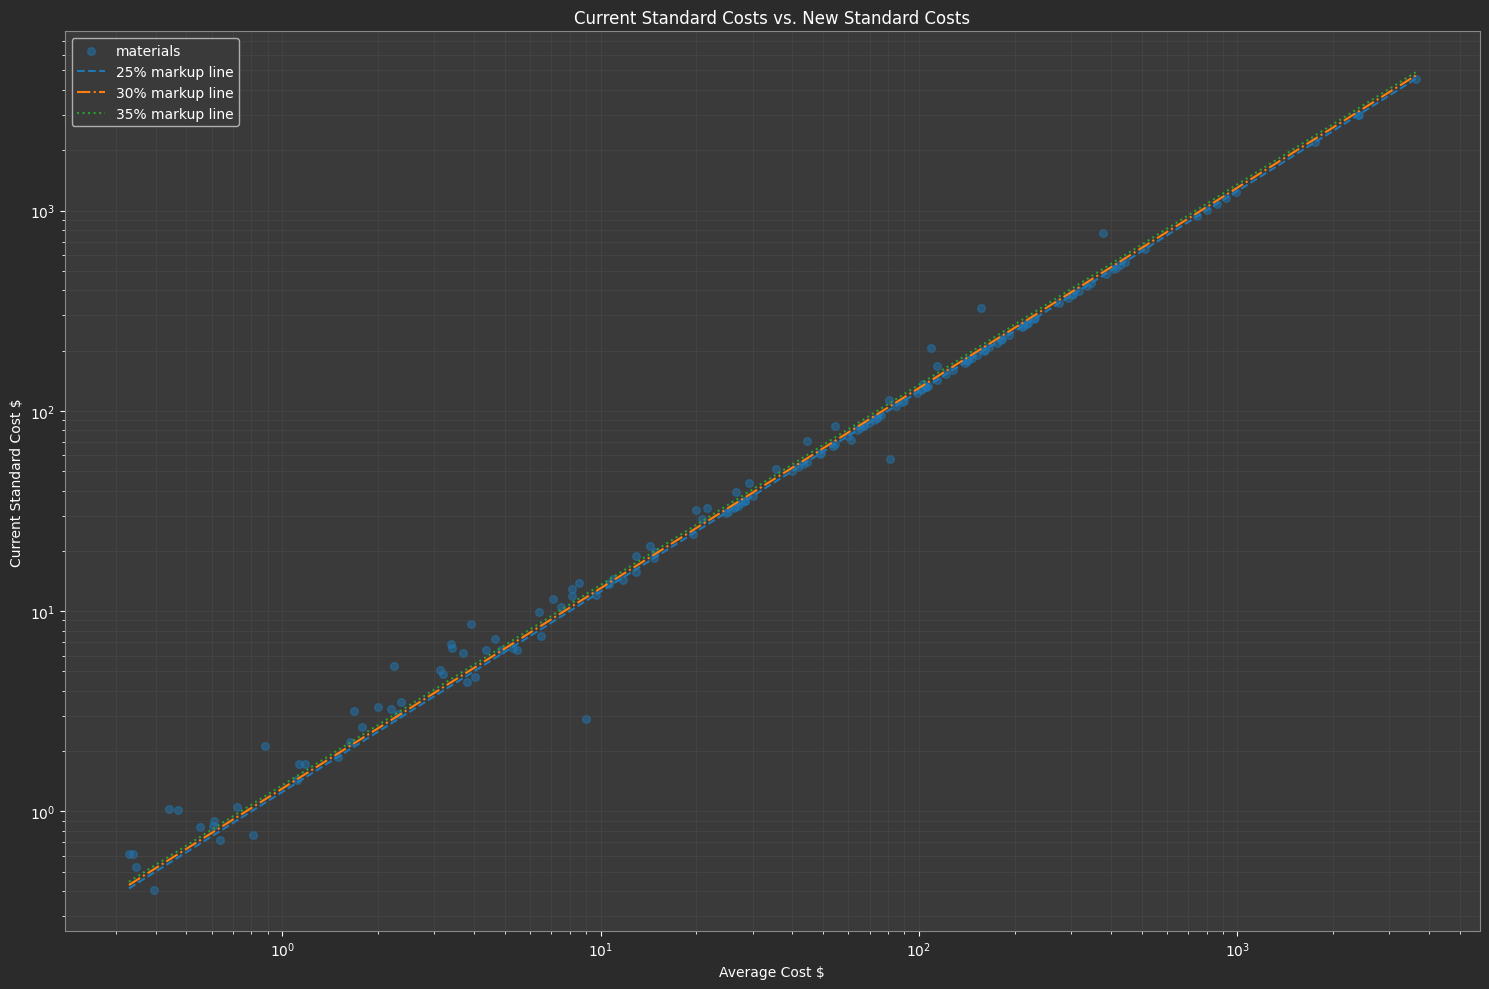

In [6]:
plt.rcParams['figure.facecolor'] = '#2b2b2b'
plt.rcParams['axes.facecolor'] = '#3a3a3a'
plt.rcParams['axes.edgecolor'] = '#888'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['text.color'] = 'white'
plt.rcParams['grid.color'] = '#555'
plt.rcParams['axes.titlecolor'] = 'white'

fig, ax = plt.subplots(figsize=(15, 10))
ax.scatter(valid['avg_cost'], valid['std_cost'], alpha=0.5, s=30, label='materials')
x = np.linspace(valid['avg_cost'].min(), valid['avg_cost'].max(), 100)
for m, style in zip(markups, ['--', '-.', ':']):
    ax.plot(x, x * (1 + m), style, label=f'{int(m*100)}% markup line')

ax.set_xlabel('Average Cost $')
ax.set_ylabel('Current Standard Cost $')
ax.set_title('Current Standard Costs vs. New Standard Costs')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

Material items above a markup line have current standard costs higher (potential overpricing). Items below the line are currently priced under the new markup (possible underpricing of final sales).

## Materials w/ Current Standard Costs Under Lowest Markup (25%)
Material items where the smallest markup (25%) exceeds the current standard cost. <br>
These are most underpriced items w/ current standard costs. Even the lowest 25% markup would increase their standard costs.

In [7]:
above = valid[valid['diff_25'] > 0].sort_values('diff_25', ascending=False)
print(f'Rows Where 25% Markup > Current Standard = {len(above)}')
above[['item_no', 'item_desc_1', 'avg_cost', 'std_cost', 'new_std_25', 'diff_25']].style.format({'avg_cost': '${:,.2f}', 'std_cost': '${:,.2f}', 'new_std_25': '${:,.2f}', 'diff_25': '${:,.2f}'})

Rows Where 25% Markup > Current Standard = 24


,item_no,item_desc_1,avg_cost,std_cost,new_std_25,diff_25
160,302052500100,PVC ROD GRAY,$81.33,$57.58,$101.66,$44.09
107,302006250200,5/8 PVC HEX ROD,$8.99,$2.89,$11.24,$8.35
157,302045000100,PVC ROD GRAY,$61.07,$71.61,$76.34,$4.74
136,3020200001USA,"2"" DIAMETER GREY PVC ROD",$6.49,$7.50,$8.11,$0.62
143,302025000100,PVC ROD GRAY,$12.94,$15.60,$16.18,$0.59
133,302017501100,PVC ROD WHITE,$5.47,$6.38,$6.84,$0.46
123,302013750100,PVC ROD GRAY,$4.04,$4.67,$5.05,$0.37
127,3020150001USA,"1 1/2"" DIAMETER GREY PVC ROD",$3.81,$4.40,$4.76,$0.36
142,302023750100,PVC ROD GRAY,$11.72,$14.32,$14.65,$0.33
98,302003751100,PVC ROD WHITE,$0.81,$0.76,$1.01,$0.25
